In [21]:
import numpy as np
from mnist import MNIST
import matplotlib as plt
from sklearn.neighbors import NearestNeighbors
from clazz.CustomKMeans import CustomKMeans

In [22]:
from clazz.DisplayUtil import *

<h3>Preparing Data</h3>

In [23]:
data_path = 'dataset/MNIST/'
mnist = MNIST(data_path)
train_images, train_labels = mnist.load_training()

<h3>K-Means Implementation</h3>

In [24]:
# get test dataset for mnist
X = np.array(train_images)
print(f'X shape = {X.shape}')

X shape = (60000, 784)


### Scale Data

In [25]:
# Scale Data 
X = X / 255.0
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784))

### Train Data

In [26]:
K = 10

In [27]:
kmeans = CustomKMeans(n_clusters=K).fit(X)
predicted_label = kmeans.predict(X)

In [28]:
predicted_label

array([0, 9, 8, ..., 0, 5, 1], shape=(60000,))

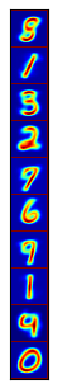

In [29]:
A = display_network(kmeans.centroids.T, K, 1)
f1 = plt.imshow(A, interpolation='nearest', cmap = "jet")
f1.axes.get_xaxis().set_visible(False)
f1.axes.get_yaxis().set_visible(False)
plt.show()

In [30]:
n = 20
'''
Each image in MNIST is 28 pixels wide x 28 pixels high.
When the 2D image is flattened into a 1D vector, we get:
28 x 28 = 784 features/pixels.
'''
X1 = np.zeros((n*K, 28*28))
X2 = np.zeros((n*K, 28*28))
for k in range (K):
    # Step 1: Get all data points belonging to cluster k.
    Xk = X[predicted_label == k, :]
    # Step 2: Find the N0 nearest points to the centroid of cluster k.
    center_k = [kmeans.centroids[k]]
    neighbor = NearestNeighbors(n_neighbors=n).fit(Xk)
    distance, nearest_id = neighbor.kneighbors(center_k, n)
    # Step 3: Store in X1 - the points closest to the centroid
    X1[n*k : n*k + n, :] = Xk[nearest_id, :]
    # Step 4: Store in X2 - the first N0 points of the cluster.
    X2[n*k : n*k + n, :] = Xk[:n, :]


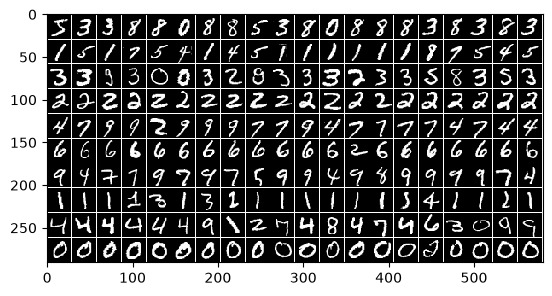

In [31]:
A = display_network(X2.T, K, n)
f2 = plt.imshow(A, interpolation='nearest' )
plt.gray()
plt.show()